# [LAB 09] 1. 선형회귀의 이해
## #01. 준비작업
### 1. 라이브러리 참조

In [3]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
from pandas import DataFrame

# 선형회귀를 위한 참조
from statsmodels.api import add_constant, OLS
from statsmodels.formula.api import ols as formula_ols

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.21

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.21, 최신 버전: 0.5.23)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



### 2. 데이터 가져오기

In [4]:
origin = load_data('cars')
origin.head()

📚 자동차의 속도(speed)에 따른 제동거리(dist) 조사 데이터 (출처: R 기본 데이터)

field    description
-------  -------------
speed    속도
dist     제동거리



,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## #02. 탐색적 데이터 분석
### 1. 종속변수와 독립변수간의 상관분석

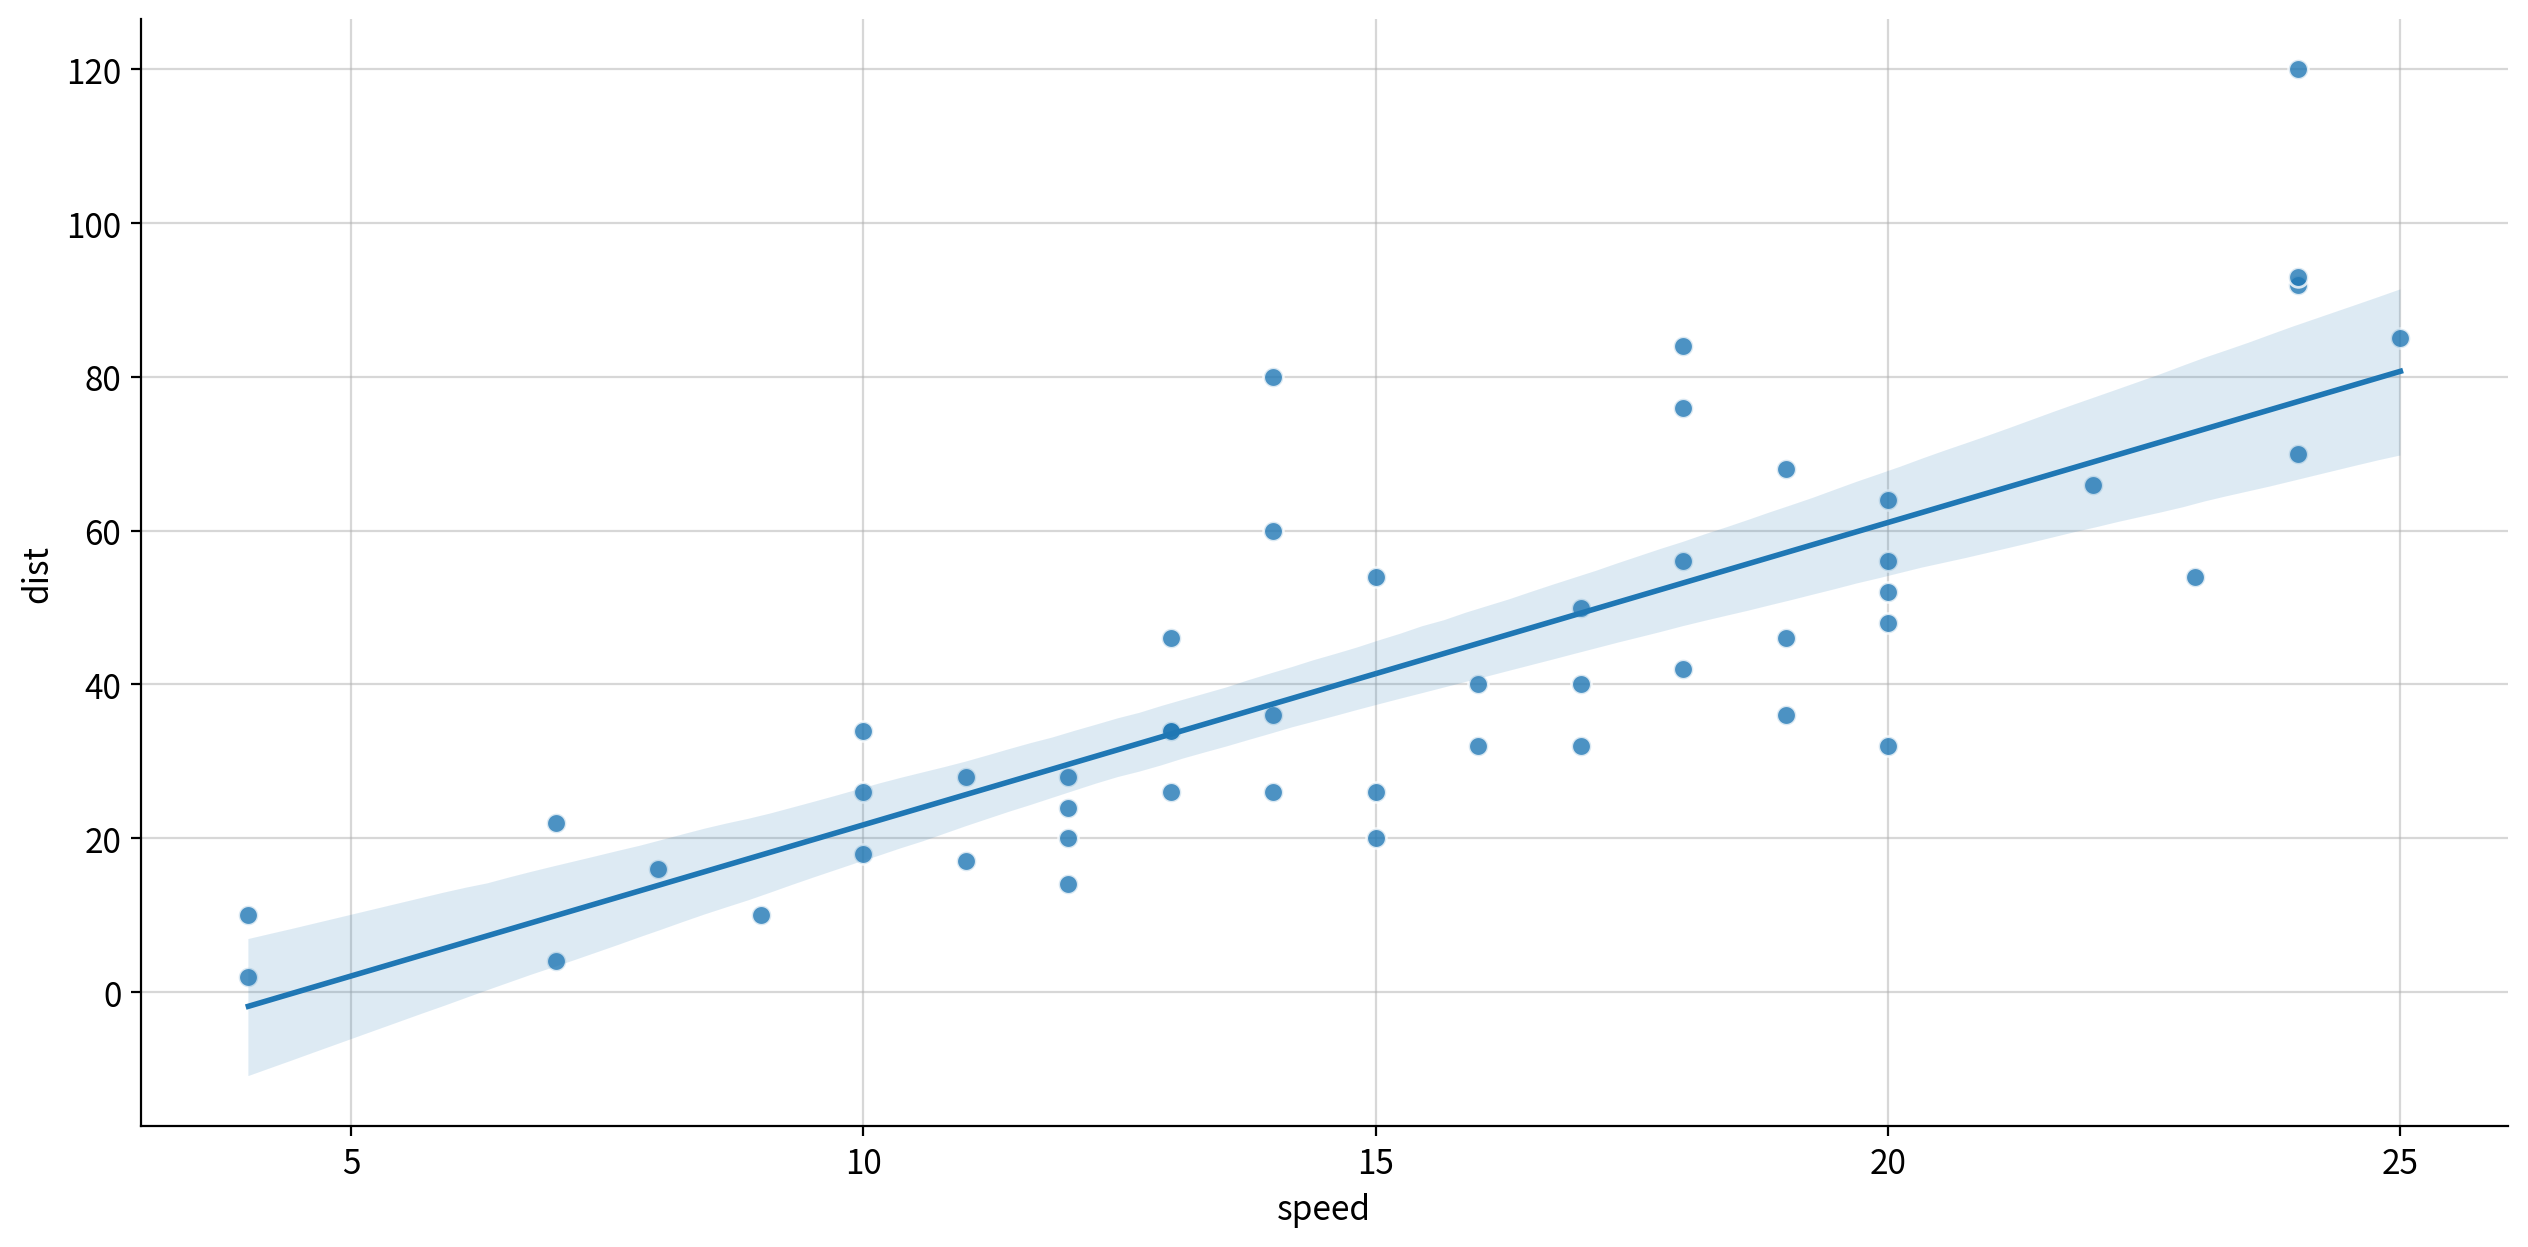

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
speed,dist,Pearson,0.807,0.000,Strong,True,True,True,True,False,False


In [5]:
my_stats.correlation(origin, 'speed', 'dist', plot=True)

- 자동차 속도와 제동거리는 선형성을 충족하고 양의 상관관계가 있는 것으로 보인다.

## #03. 행렬기반 방식의 단순선형회귀
### 1. 독립변수 행렬 준비

In [6]:
x= origin[['speed']]
x.head()

,speed
0,4
1,4
2,7
3,7
4,8


### 2. 종속변수 준비
- 종속변수는 Series 객체 형태로 준비한다.

In [7]:
y=origin['dist']
y.head()

0     2
1    10
2     4
3    22
4    16
Name: dist, dtype: int64

### 3. 상수항 추가
- y=ax+b 형태가 기본형이므로 b 역할을 하기 위한 상수항을 추가해야 한다.
    - 상수항이 없다면 절편이 0으로 고정된 잘못된 모델이 만들어질 수 있다.

In [8]:
x_input = add_constant(x)
x_input.head()

,const,speed
0,1.000,4
1,1.000,4
2,1.000,7
3,1.000,7
4,1.000,8


### 4. 회귀분석 수행

In [9]:
# OLS 모델 객체 생성
# -> 이 단계에서는 아직 학습(fit)되지 않은 '모형의 틀'만 만들어짐
model = OLS(y, x_input)

# 모델적합(fit)
#-> 데이터를 이용해 회귀계수(B(beta))를 추정하고, 모델을 완성하는 단계
fit =model.fit()

# 적합된 모델 객체의 분석 결과 확인
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        12:24:49   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

## #04. formaula API 방식의 선형회귀
### 1. 단순선형회귀 구현
    - 상수항을 자동 처리하므로 직접 추가하지 않아도 된다.

In [10]:
# 학습모델 객체 생성
model = formula_ols('dist ~ speed', data=origin)

# 모델 적합
fit= model.fit()

# 분석결과 확인
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        12:24:49   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

## #05. 실제 데이터와 모형의 예측값 비교
### 1. 원본 데이터 + 가상 데이터 (예측용)

In [11]:
df = origin.copy()

# 최고 속도 이후의 5단계 값을 가상으로 추가한다.
for i in range(1,6):
    df.loc[len(df)]=[df["speed"].max()+i, None]

df.tail(5)

,speed,dist
50,26.000,NaN
51,28.000,NaN
52,31.000,NaN
53,35.000,NaN
54,40.000,NaN


### 2. 예측값 생성
- 분석 모형 x에 해당하는 speed를 넣어 y에 해당하는 dist가 계산된 값

In [12]:
# 예측값을 생성하기 위해서는 상수항이 추가된 데이터를 사용해야 한다.
predict_input = add_constant(df[['speed']])
df['pred'] = fit.predict(predict_input)
df.tail()

,speed,dist,pred
50,26.000,NaN,84.664
51,28.000,NaN,92.528
52,31.000,NaN,104.326
53,35.000,NaN,120.055
54,40.000,NaN,139.717


### 3. 시각화를 위해 long 타입으로 재배치

In [13]:
df_melt = df.melt(
    id_vars='speed',            # speed는 그대로 둠
    value_vars=['dist','pred'], # long 형태로 변환할 변수
    var_name='variable',        # 명목형 변수명
    value_name='value'          # 값 변수명
)

df_melt.tail(10)

,speed,variable,value
100,24.000,pred,76.799
101,24.000,pred,76.799
102,24.000,pred,76.799
103,24.000,pred,76.799
104,25.000,pred,80.731
105,26.000,pred,84.664
106,28.000,pred,92.528
107,31.000,pred,104.326
108,35.000,pred,120.055
109,40.000,pred,139.717


In [14]:
df_melt.dtypes

speed       float64
variable        str
value       float64
dtype: object

### 4. 시각화 비교

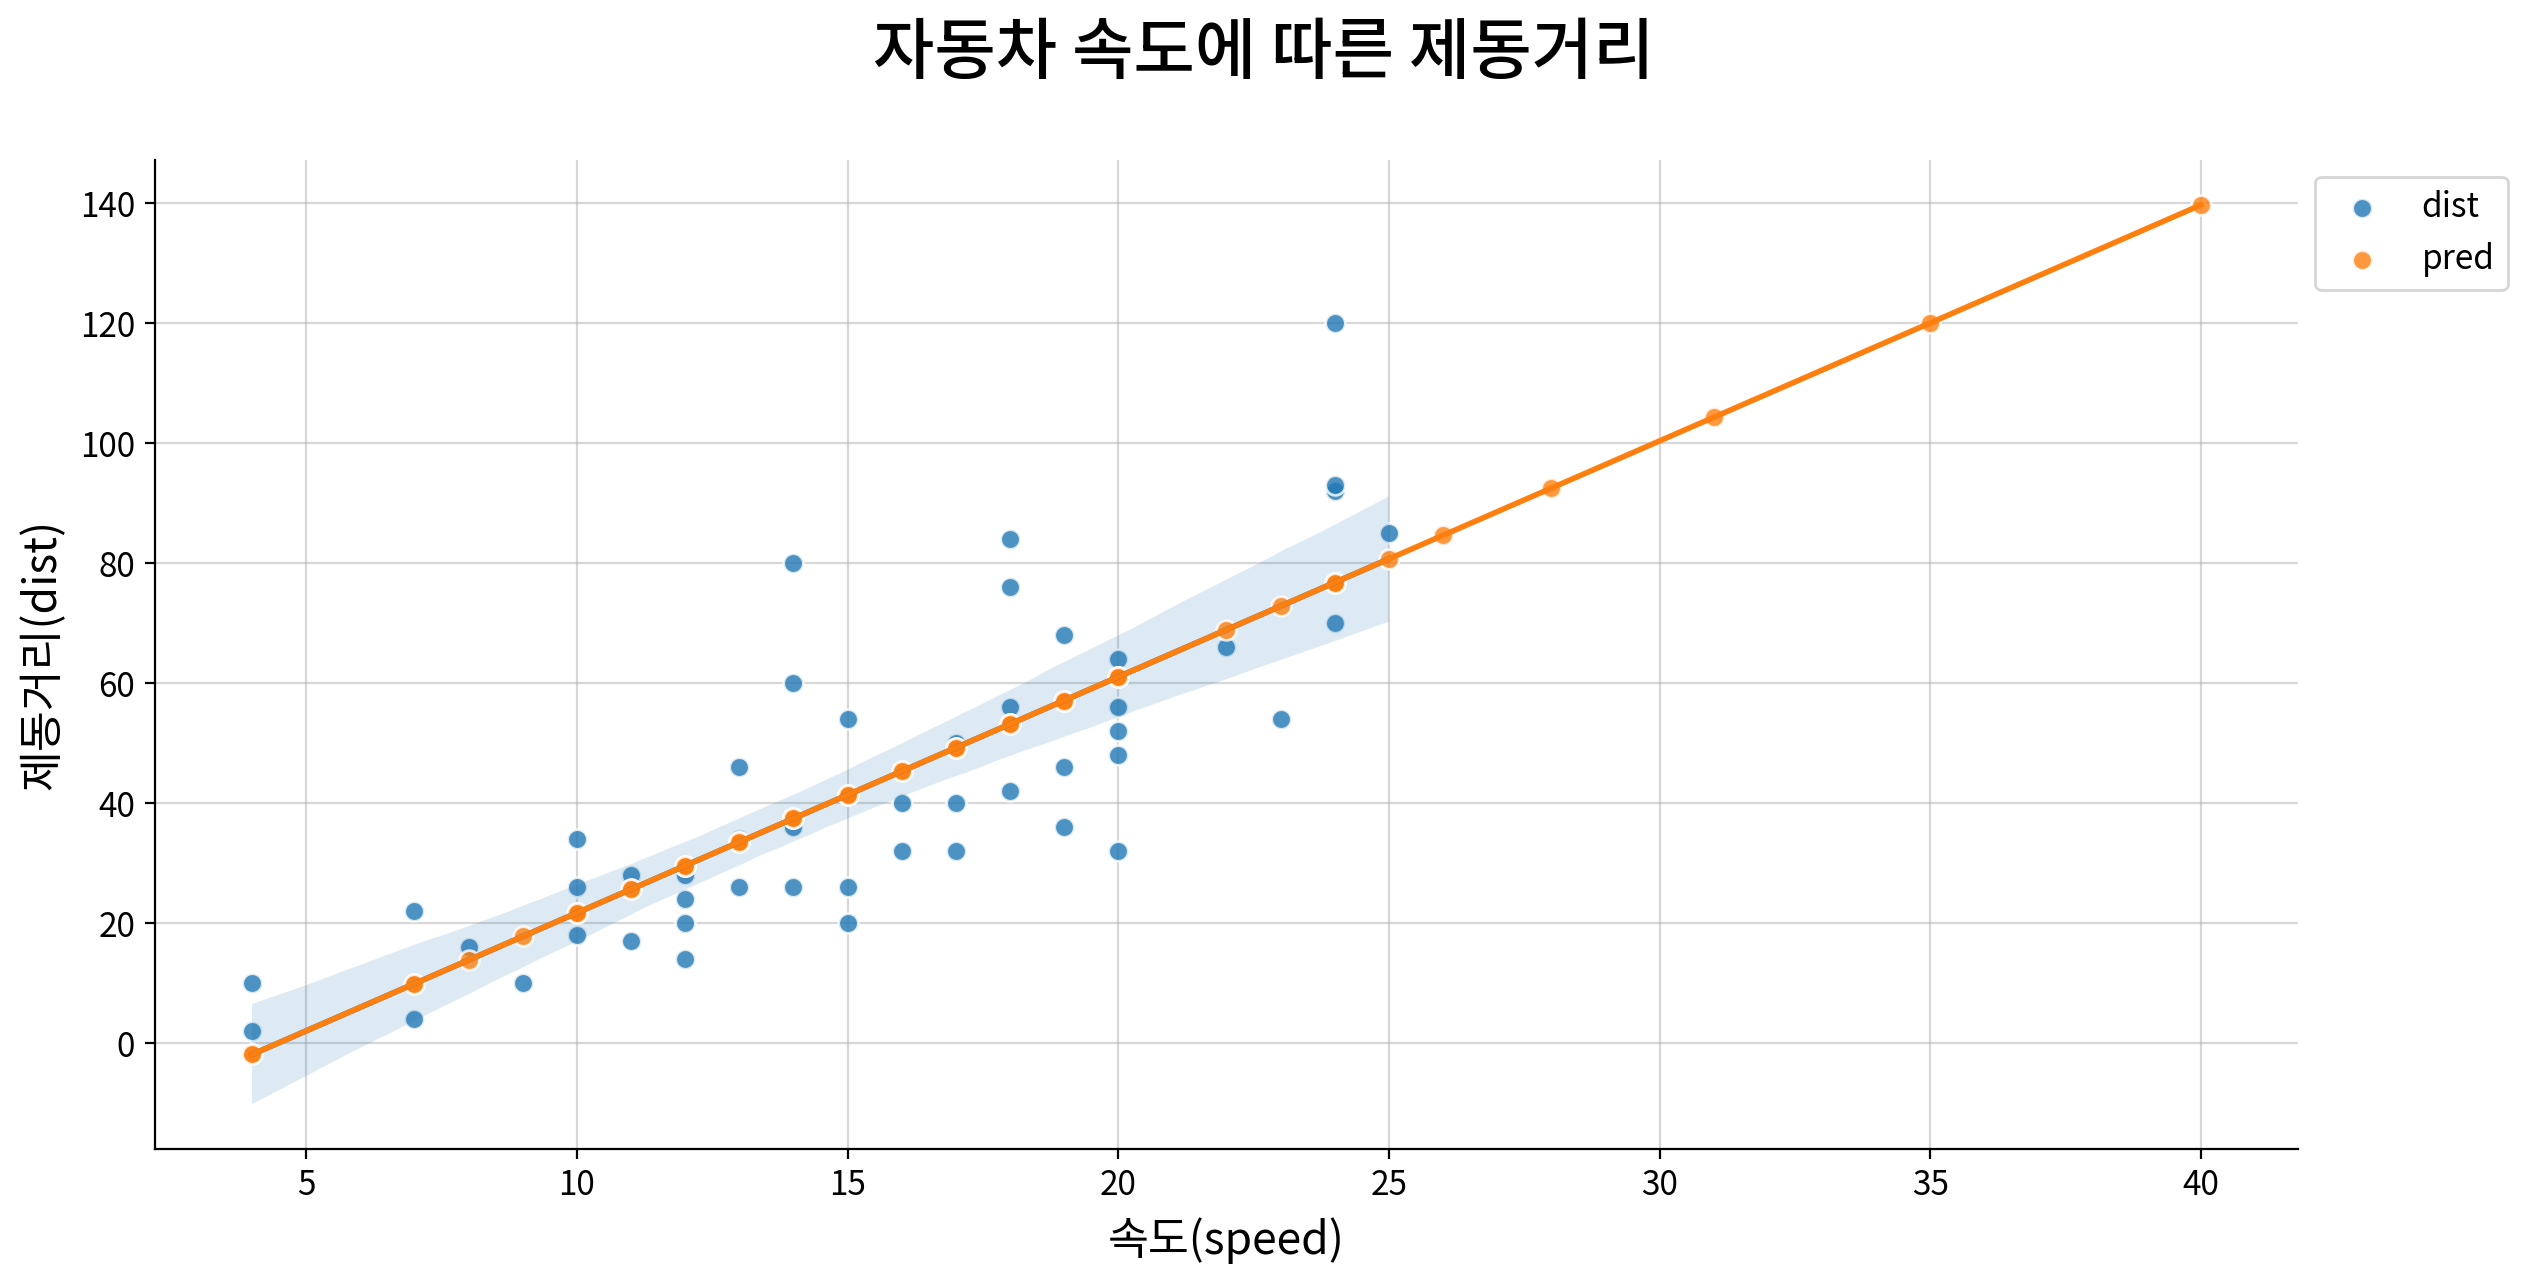

In [15]:
my_plot.lmplot(df_melt, x='speed', y='value', hue='variable', title='자동차 속도에 따른 제동거리',
               xlabel='속도(speed)', ylabel='제동거리(dist)')

## #06. 모듈화 기능 확인
### 1. 모델 적합

In [16]:
fit = my_ols.fit_model(origin, y='dist', summary=True)

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.49e-12
Time:                        12:24:49   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.5791      6.758     -2.601      0.0

### 2. 예측값 생성

In [17]:
pred = my_ols.predict(fit, origin[['speed']])

new_df = origin.copy()
new_df['pred']=pred
new_df.head()

,speed,dist,pred
0,4,2,-1.849
1,4,10,-1.849
2,7,4,9.948
3,7,22,9.948
4,8,16,13.880
